Tâm cụm khởi tạo ngẫu nhiên ban đầu:
 [[ 4.8111717   9.05986008]
 [ 4.16625513 11.1061108 ]
 [ 9.43586613  0.41498765]]


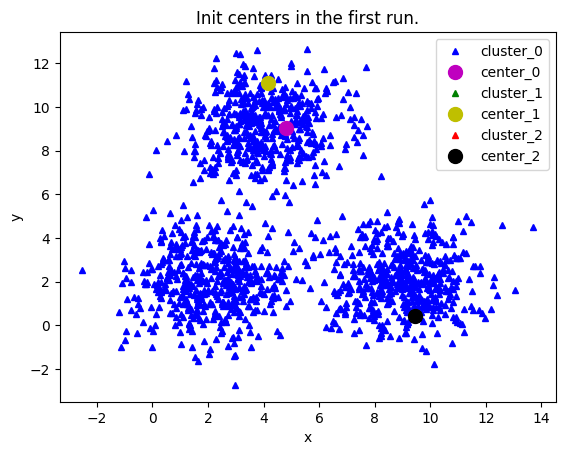

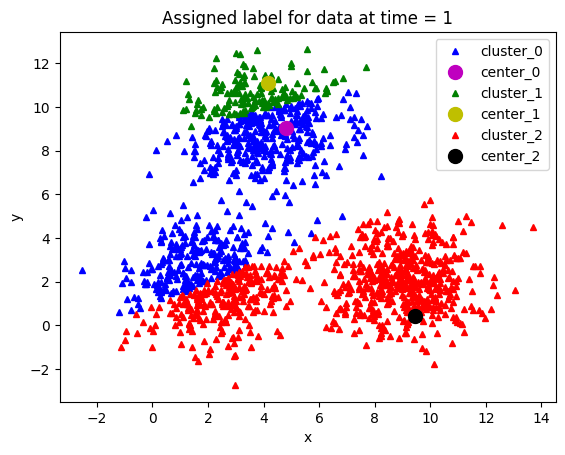

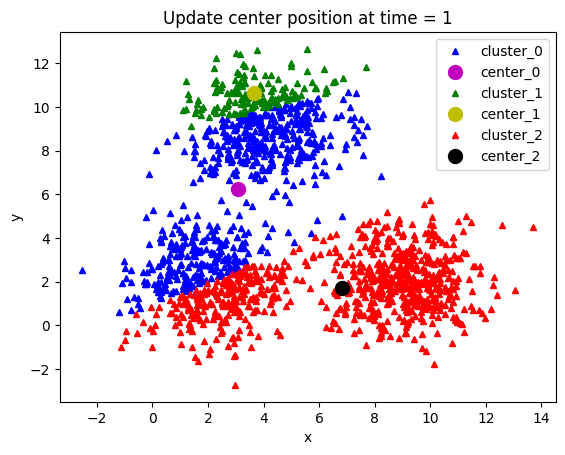

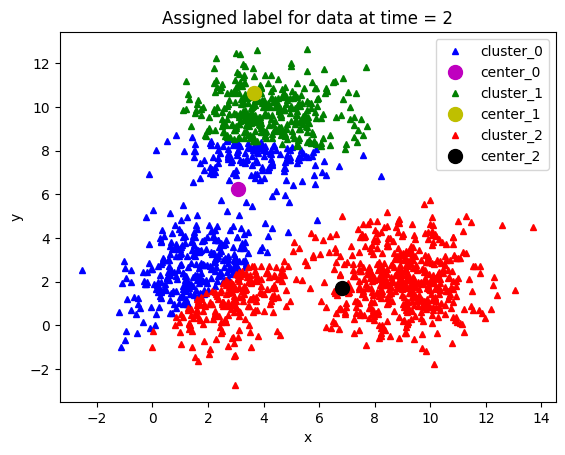

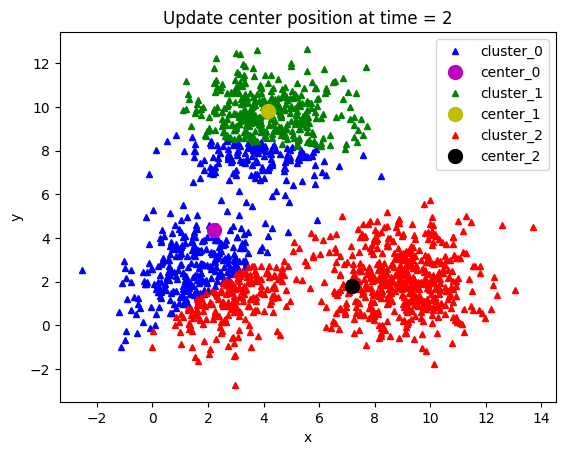

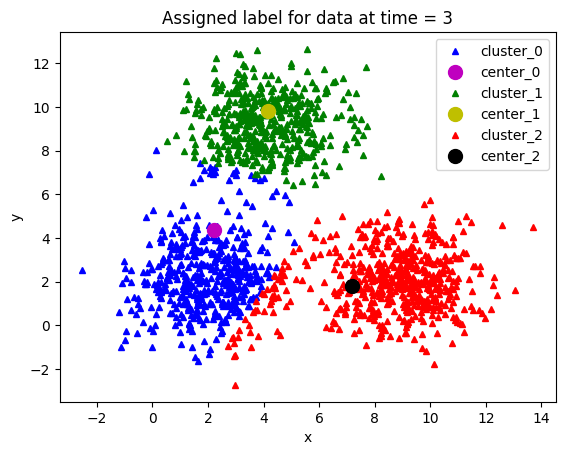

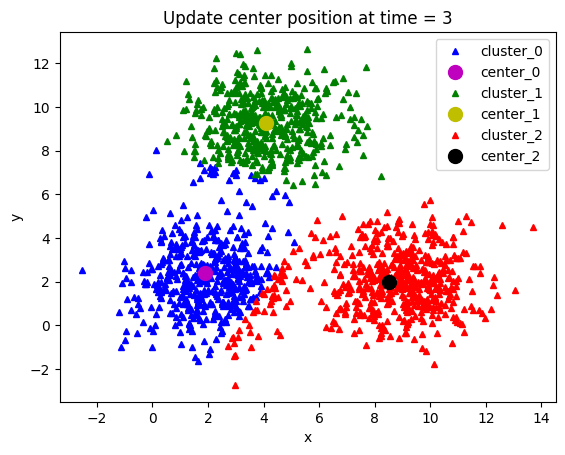

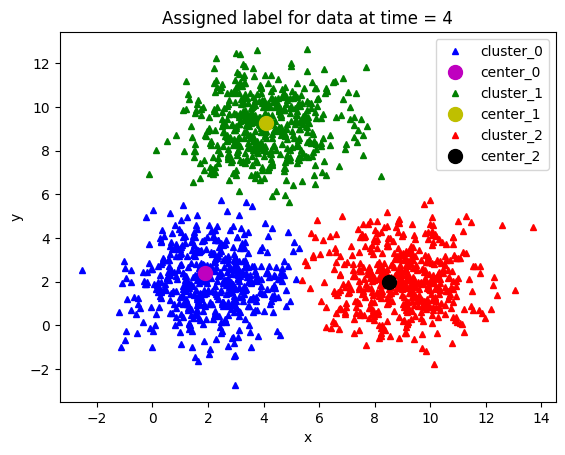

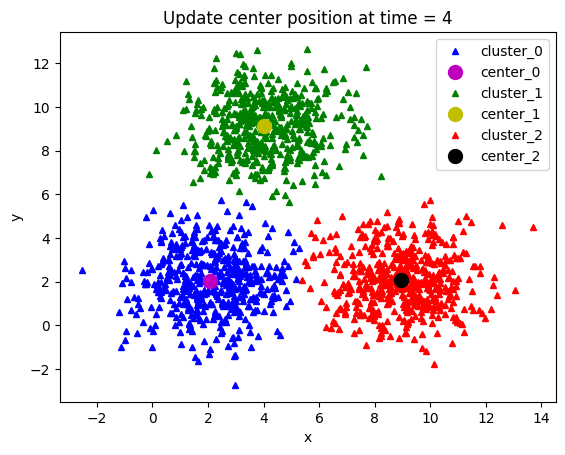

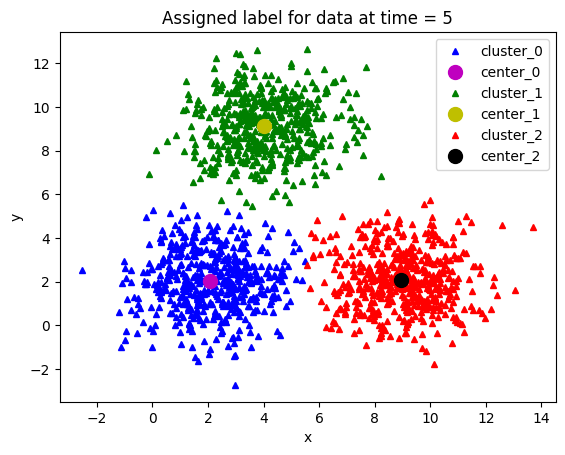

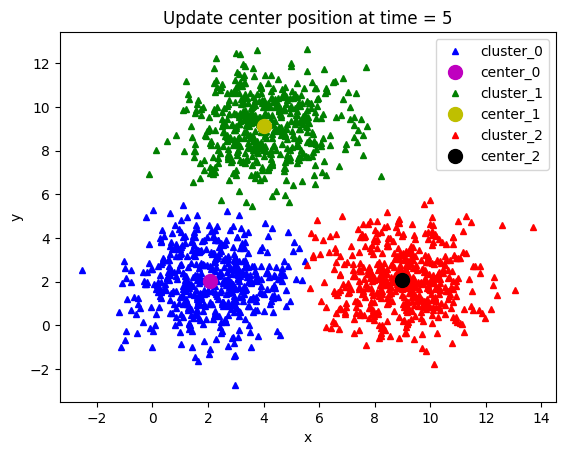

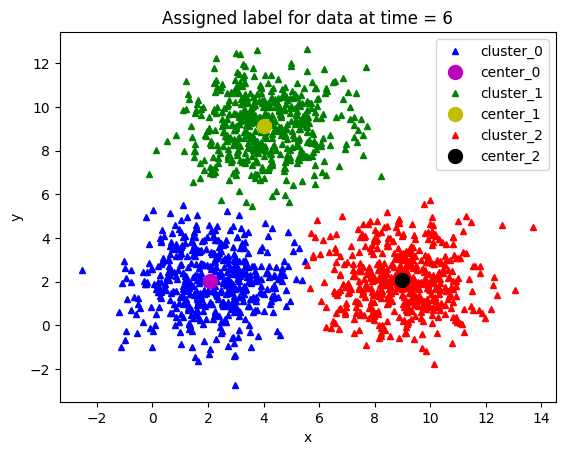

Done! Kmeans has converged after 5 times
Tọa độ tâm cụm cuối cùng thu được:
 [[2.08906686 2.02268858]
 [4.00673115 9.1148488 ]
 [8.97704127 2.06867755]]


In [ ]:
"""K-Means"""
"""Bai 1"""
import numpy as np                  # Thư viện tính toán ma trận và đại số tuyến tính [cite: 38]
import matplotlib.pyplot as plt    # Thư viện dùng để vẽ đồ thị trực quan hóa dữ liệu [cite: 38]
from scipy.spatial.distance import cdist  # Thư viện hỗ trợ tính khoảng cách giữa các điểm [cite: 38]

# =====================================================================
# BƯỚC 1: KHỞI TẠO DỮ LIỆU MẪU (Bao gồm 1500 điểm xoay quanh 3 tâm cụm) [cite: 39, 40]
# =====================================================================
means = [[2, 2], [9, 2], [4, 9]]    # Định nghĩa trước 3 tâm cụm kỳ vọng [cite: 39, 40]
cov = [[2, 0], [0, 2]]              # Ma trận hiệp biến (độ phân tán của dữ liệu xung quanh tâm) [cite: 40]
n_samples = 500                     # Số lượng mẫu cho mỗi cụm [cite: 40]
n_cluster = 3                       # Số lượng cụm cần phân chia [cite: 40]

# Tạo ngẫu nhiên dữ liệu phân bố chuẩn đa biến theo các tâm cụm phía trên [cite: 40]
X0 = np.random.multivariate_normal(means[0], cov, n_samples)
X1 = np.random.multivariate_normal(means[1], cov, n_samples)
X2 = np.random.multivariate_normal(means[2], cov, n_samples)

# Gộp 3 tập dữ liệu trên lại thành một tập dữ liệu X lớn gồm 1500 dòng và 2 cột (x, y) [cite: 40]
X = np.concatenate((X0, X1, X2), axis = 0)

# =====================================================================
# BƯỚC 2: ĐỊNH NGHĨA CÁC HÀM XỬ LÝ TRONG K-MEANS
# =====================================================================

# Hàm khởi tạo n_cluster tâm cụm ngẫu nhiên ban đầu từ tập dữ liệu X [cite: 44]
def kmeans_init_centers(X, n_cluster):
    # Chọn ngẫu nhiên n_cluster chỉ mục (index) từ 0 đến số lượng dòng của X mà không trùng lặp [cite: 45, 46]
    # Trả về tọa độ của các dòng được chọn tương ứng làm tâm cụm ban đầu [cite: 46]
    return X[np.random.choice(X.shape[0], n_cluster, replace=False)]

# Hàm dự đoán nhãn (cụm) cho từng điểm dữ liệu dựa trên khoảng cách tới các tâm cụm [cite: 47, 48]
def kmeans_predict_labels(X, centers):
    # Tính toán ma trận khoảng cách từ tất cả các điểm trong X tới các tâm cụm hiện tại [cite: 48]
    D = cdist(X, centers)
    # Với mỗi điểm dữ liệu, tìm chỉ số (0, 1 hoặc 2) của tâm cụm có khoảng cách ngắn nhất [cite: 48]
    return np.argmin(D, axis = 1)

# Hàm cập nhật lại vị trí mới của các tâm cụm [cite: 49, 50]
def kmeans_update_centers(X, labels, n_cluster):
    # Khởi tạo một ma trận chứa tọa độ tâm cụm mới toàn số 0 [cite: 50]
    centers = np.zeros((n_cluster, X.shape[1]))
    for k in range(n_cluster):
        # Trích xuất toàn bộ các điểm dữ liệu đang được gán nhãn thuộc về cụm thứ k [cite: 50]
        Xk = X[labels == k, :]
        # Tính toán giá trị trung bình tọa độ (trọng tâm) của các điểm thuộc cụm k [cite: 50]
        centers[k,:] = np.mean(Xk, axis = 0)
    return centers

# Hàm kiểm tra tính hội tụ (điều kiện dừng thuật toán) [cite: 51, 52]
def kmeans_has_converged(centers, new_centers):
    # Chuyển danh sách tọa độ các tâm cụm cũ và mới thành dạng set tập hợp [cite: 52]
    # Nếu hai tập hợp tọa độ này hoàn toàn giống nhau (tâm cụm không đổi vị trí nữa) thì trả về True [cite: 52]
    return (set([tuple(a) for a in centers]) == set([tuple(a) for a in new_centers]))

# Hàm trực quan hóa dữ liệu và tâm cụm lên đồ thị hình vẽ [cite: 53, 54, 55]
def kmeans_visualize(X, centers, labels, n_cluster, title):
    plt.xlabel('x')   # Đặt tên nhãn cho trục hoành [cite: 55]
    plt.ylabel('y')   # Đặt tên nhãn cho trục tung [cite: 55]
    plt.title(title)  # Đặt tiêu đề cho đồ thị vẽ [cite: 55]
    plt_colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w']   # Danh sách bảng màu hỗ trợ biểu diễn [cite: 55]

    for i in range(n_cluster):
        data = X[labels == i]   # Lấy danh sách điểm dữ liệu của cụm i hiện tại [cite: 55]
        # Vẽ các điểm thuộc cụm i lên đồ thị dưới dạng hình tam giác '^' [cite: 56]
        plt.plot(data[:, 0], data[:, 1], plt_colors[i] + '^', markersize=4, label='cluster_' + str(i))
        # Vẽ vị trí tâm cụm i hiện tại dưới dạng hình tròn 'o' lớn hơn để dễ phân biệt [cite: 56]
        plt.plot(centers[i][0], centers[i][1], plt_colors[i + 4] + 'o', markersize=10, label='center_' + str(i))

    plt.legend()   # Hiển thị bảng chú thích góc đồ thị [cite: 56]
    plt.show()     # Lệnh hiển thị cửa sổ đồ thị ra màn hình [cite: 56]

# =====================================================================
# BƯỚC 3: HÀM ĐIỀU KHIỂN CHÍNH TOÀN BỘ THUẬT TOÁN K-MEANS [cite: 57]
# =====================================================================
def kmeans(init_centers, init_labels, X, n_cluster):
    centers = init_centers  # Gán tâm cụm ban đầu [cite: 58]
    labels = init_labels    # Gán nhãn ban đầu [cite: 58]
    times = 0               # Biến đếm số lần lặp thực hiện [cite: 58]

    while True:
        # 1. Dự đoán lại nhãn mới của dữ liệu dựa trên các vị trí tâm cụm hiện hành [cite: 58]
        labels = kmeans_predict_labels(X, centers)
        # Vẽ đồ thị biểu diễn kết quả gán nhãn [cite: 58]
        kmeans_visualize(X, centers, labels, n_cluster, 'Assigned label for data at time = ' + str(times + 1))

        # 2. Cập nhật lại tọa độ vị trí các tâm cụm mới dựa trên nhãn vừa gán [cite: 58]
        new_centers = kmeans_update_centers(X, labels, n_cluster)

        # 3. Kiểm tra xem thuật toán đã đạt trạng thái đứng yên hội tụ chưa [cite: 58]
        if kmeans_has_converged(centers, new_centers):
            break   # Nếu vị trí tâm cụm không thay đổi nữa thì thoát khỏi vòng lặp [cite: 58]

        centers = new_centers  # Cập nhật tâm cụm cũ thành tâm cụm mới cho lần lặp kế tiếp [cite: 58]
        # Vẽ đồ thị biểu diễn vị trí tâm cụm mới sau khi cập nhật [cite: 58]
        kmeans_visualize(X, centers, labels, n_cluster, 'Update center position at time = ' + str(times + 1))
        times += 1

    return (centers, labels, times)

# =====================================================================
# BƯỚC 4: THỰC THI THỬ NGHIỆM K-MEANS CLUSTERING [cite: 60]
# =====================================================================
init_centers = kmeans_init_centers(X, n_cluster)
print("Tâm cụm khởi tạo ngẫu nhiên ban đầu:\n", init_centers)

init_labels = np.zeros(X.shape[0]) # Khởi tạo nhãn ban đầu mặc định toàn cụm 0
kmeans_visualize(X, init_centers, init_labels, n_cluster, 'Init centers in the first run.')

# Tiến hành gọi hàm chạy thuật toán lặp tìm tâm cụm
centers, labels, times = kmeans(init_centers, init_labels, X, n_cluster)
print('Done! Kmeans has converged after', times, 'times')
print("Tọa độ tâm cụm cuối cùng thu được:\n", centers)

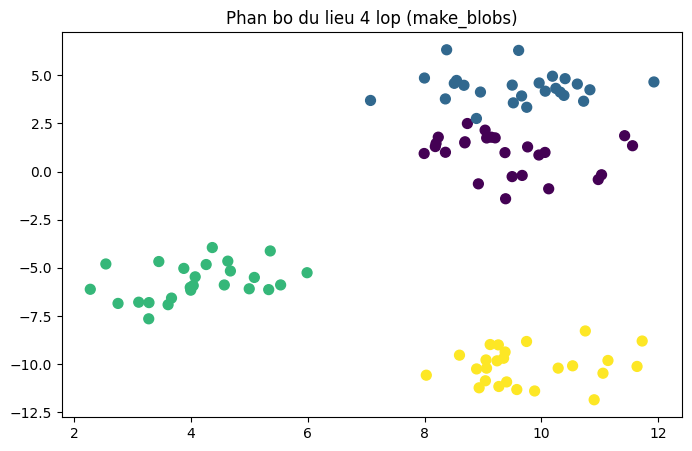

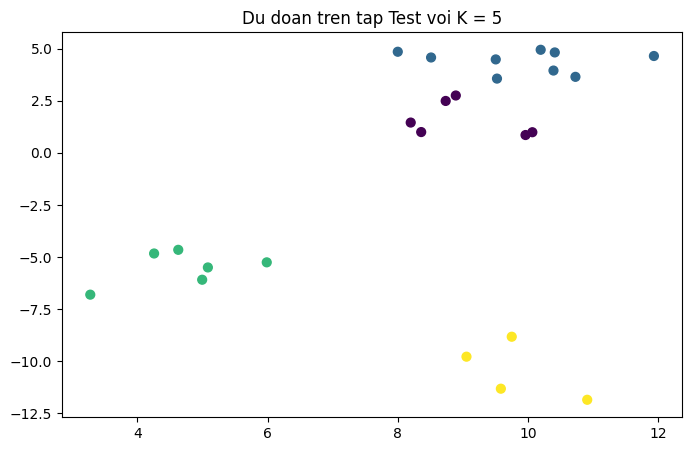

Tham so K tot nhat tim duoc tu tu dong kiem tra: {'n_neighbors': np.int64(2)}
Nhan du doan cua thuật toan KNN tu code cho diem (1,3) la: Class 0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

# ==========================================
# BƯỚC 2 & 3: KHỞI TẠO VÀ XEM DỮ LIỆU PHÂN LỚP
# ==========================================
X, y = make_blobs(n_samples=100, n_features=2, centers=4, cluster_std=1, random_state=4)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, marker='o', s=50, cmap='viridis')
plt.title("Phan bo du lieu 4 lop (make_blobs)")
plt.show()

# ==========================================
# BƯỚC 4: CHIA TẬP TRAIN / TEST (75% - 25%)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# ==========================================
# BƯỚC 5 & 6: ĐÁNH GIÁ MÔ HÌNH BẰNG THƯ VIỆN ĐỐI VỚI K=5 VÀ K=1
# ==========================================
# Với K = 5
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train, y_train)
y_pred_5 = knn5.predict(X_test)

# Với K = 1
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, y_train)
y_pred_1 = knn1.predict(X_test)

# Trực quan hóa so sánh kết quả k=5
plt.figure(figsize=(8, 5))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred_5, marker='o', s=40, cmap='viridis')
plt.title("Du doan tren tap Test voi K = 5")
plt.show()

# ==========================================
# BƯỚC 8 & 9: TỰ ĐỘNG TÌM K TỐT NHẤT QUA GRIDSEARCHCV
# ==========================================
knn_grid = GridSearchCV(estimator=KNeighborsClassifier(), param_grid={'n_neighbors': np.arange(1, 10)}, cv=5)
knn_grid.fit(X, y)
print("Tham so K tot nhat tim duoc tu tu dong kiem tra:", knn_grid.best_params_)

# ==========================================
# TỰ CÀI ĐẶT HÀM KNN THỦ CÔNG (TỪ BƯỚC 95)
# ==========================================
def KNN_custom(X_train, X_test, y_train, k):
    num_test = X_test.shape[0]   # Số lượng mẫu test
    num_train = X_train.shape[0] # Số lượng mẫu train

    # Ma trận chứa khoảng cách từ mỗi điểm test tới mọi điểm train
    y_pred_dist = np.zeros((num_test, num_train))

    # Tính khoảng cách Euclidean
    for i in range(num_test):
        for j in range(num_train):
            y_pred_dist[i, j] = np.sqrt(np.sum(np.power(X_test[i, :] - X_train[j, :], 2)))

    results = []
    # Sắp xếp và lấy K láng giềng gần nhất
    for i in range(len(y_pred_dist)):
        zipped = zip(y_pred_dist[i, :], y_train)
        res = sorted(zipped, key=lambda x: x[0])
        results_topk = res[:k]

        # Đếm số lượng của mỗi lớp (voting)
        classes = {}
        for _, j in results_topk:
            j = int(j)
            if j not in classes:
                classes[j] = 1
            else:
                classes[j] = classes[j] + 1

        # Lấy lớp có số lượng xuất hiện nhiều nhất
        results.append(max(classes, key=classes.get))

    return np.array(results)

# --- Thử nghiệm hàm KNN tự viết với tập dữ liệu mới ---
X_new, y_new = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1, random_state=4)
X_test_point = np.array([(1, 3)]) # Điểm cần dự đoán dán nhãn

# Dự đoán nhãn cho điểm (1, 3) với k=3 láng giềng
custom_results = KNN_custom(X_new, X_test_point, y_new, k=3)
print(f"Nhan du doan cua thuật toan KNN tu code cho diem (1,3) la: Class {custom_results[0]}")

Tâm cụm khởi tạo ngẫu nhiên ban đầu:
 [[ 2.53968063  9.7362669 ]
 [ 8.81497875 -0.94503102]
 [ 2.61620248  3.17620322]]


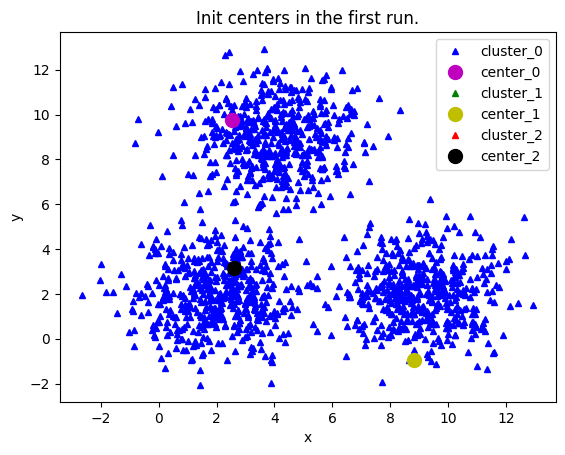

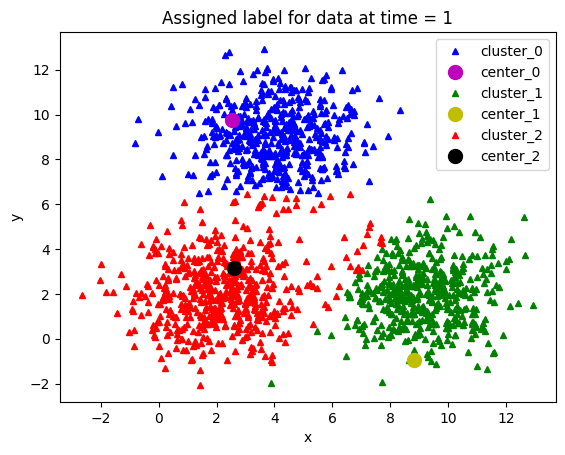

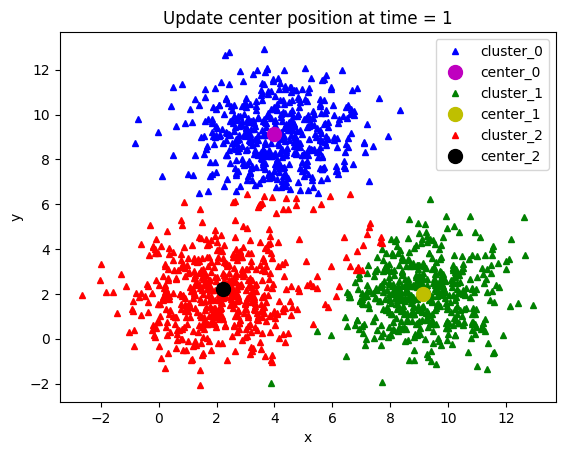

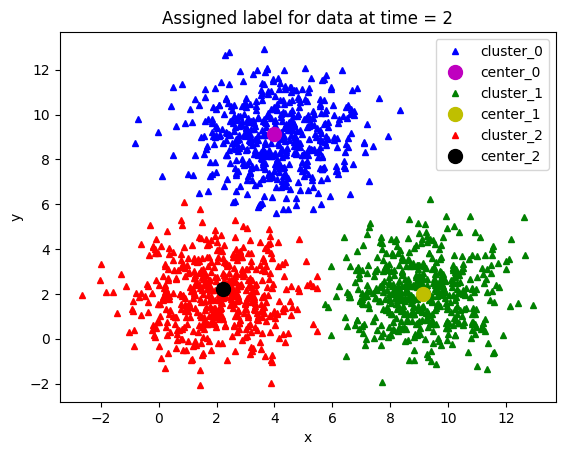

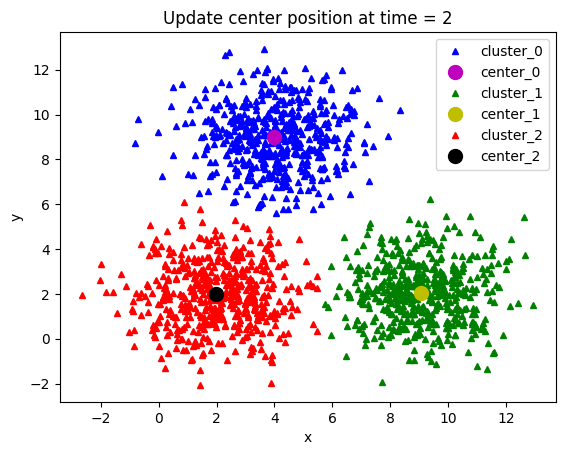

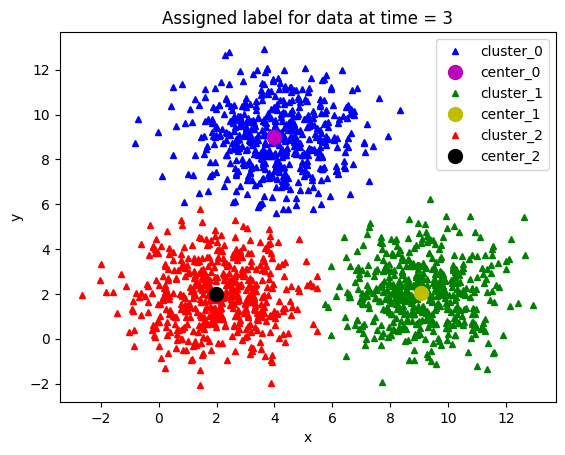

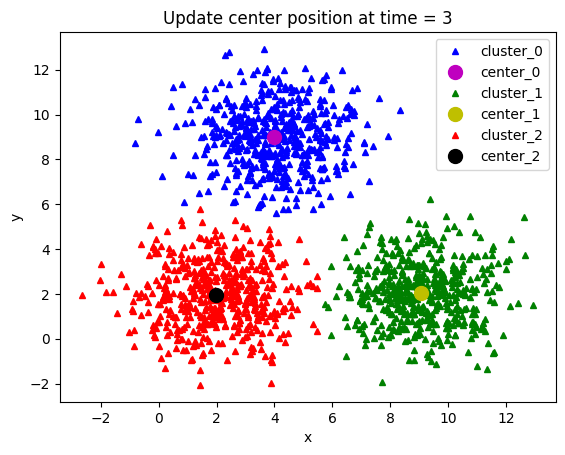

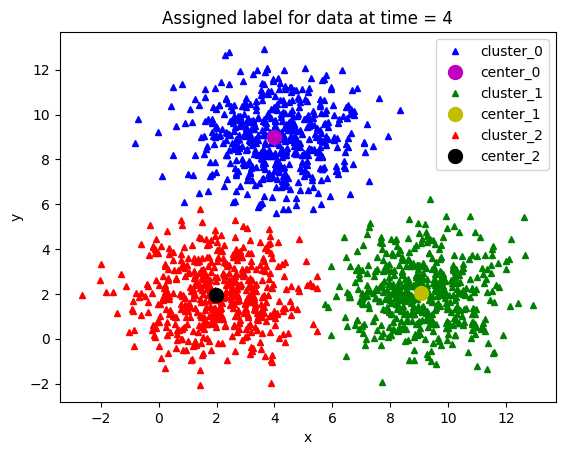

Done! Kmeans has converged after 3 times
Tọa độ tâm cụm cuối cùng thu được:
 [[3.98961278 8.99393863]
 [9.06378192 2.06141985]
 [1.98314059 1.97219539]]


In [2]:
"""K-Means"""
"""Bai 1"""
import numpy as np                  # Thư viện tính toán ma trận và đại số tuyến tính [cite: 38]
import matplotlib.pyplot as plt    # Thư viện dùng để vẽ đồ thị trực quan hóa dữ liệu [cite: 38]
from scipy.spatial.distance import cdist  # Thư viện hỗ trợ tính khoảng cách giữa các điểm [cite: 38]

# =====================================================================
# BƯỚC 1: KHỞI TẠO DỮ LIỆU MẪU (Bao gồm 1500 điểm xoay quanh 3 tâm cụm) [cite: 39, 40]
# =====================================================================
means = [[2, 2], [9, 2], [4, 9]]    # Định nghĩa trước 3 tâm cụm kỳ vọng [cite: 39, 40]
cov = [[2, 0], [0, 2]]              # Ma trận hiệp biến (độ phân tán của dữ liệu xung quanh tâm) [cite: 40]
n_samples = 500                     # Số lượng mẫu cho mỗi cụm [cite: 40]
n_cluster = 3                       # Số lượng cụm cần phân chia [cite: 40]

# Tạo ngẫu nhiên dữ liệu phân bố chuẩn đa biến theo các tâm cụm phía trên [cite: 40]
X0 = np.random.multivariate_normal(means[0], cov, n_samples)
X1 = np.random.multivariate_normal(means[1], cov, n_samples)
X2 = np.random.multivariate_normal(means[2], cov, n_samples)

# Gộp 3 tập dữ liệu trên lại thành một tập dữ liệu X lớn gồm 1500 dòng và 2 cột (x, y) [cite: 40]
X = np.concatenate((X0, X1, X2), axis = 0)

# =====================================================================
# BƯỚC 2: ĐỊNH NGHĨA CÁC HÀM XỬ LÝ TRONG K-MEANS
# =====================================================================

# Hàm khởi tạo n_cluster tâm cụm ngẫu nhiên ban đầu từ tập dữ liệu X [cite: 44]
def kmeans_init_centers(X, n_cluster):
    # Chọn ngẫu nhiên n_cluster chỉ mục (index) từ 0 đến số lượng dòng của X mà không trùng lặp [cite: 45, 46]
    # Trả về tọa độ của các dòng được chọn tương ứng làm tâm cụm ban đầu [cite: 46]
    return X[np.random.choice(X.shape[0], n_cluster, replace=False)]

# Hàm dự đoán nhãn (cụm) cho từng điểm dữ liệu dựa trên khoảng cách tới các tâm cụm [cite: 47, 48]
def kmeans_predict_labels(X, centers):
    # Tính toán ma trận khoảng cách từ tất cả các điểm trong X tới các tâm cụm hiện tại [cite: 48]
    D = cdist(X, centers)
    # Với mỗi điểm dữ liệu, tìm chỉ số (0, 1 hoặc 2) của tâm cụm có khoảng cách ngắn nhất [cite: 48]
    return np.argmin(D, axis = 1)

# Hàm cập nhật lại vị trí mới của các tâm cụm [cite: 49, 50]
def kmeans_update_centers(X, labels, n_cluster):
    # Khởi tạo một ma trận chứa tọa độ tâm cụm mới toàn số 0 [cite: 50]
    centers = np.zeros((n_cluster, X.shape[1]))
    for k in range(n_cluster):
        # Trích xuất toàn bộ các điểm dữ liệu đang được gán nhãn thuộc về cụm thứ k [cite: 50]
        Xk = X[labels == k, :]
        # Tính toán giá trị trung bình tọa độ (trọng tâm) của các điểm thuộc cụm k [cite: 50]
        centers[k,:] = np.mean(Xk, axis = 0)
    return centers

# Hàm kiểm tra tính hội tụ (điều kiện dừng thuật toán) [cite: 51, 52]
def kmeans_has_converged(centers, new_centers):
    # Chuyển danh sách tọa độ các tâm cụm cũ và mới thành dạng set tập hợp [cite: 52]
    # Nếu hai tập hợp tọa độ này hoàn toàn giống nhau (tâm cụm không đổi vị trí nữa) thì trả về True [cite: 52]
    return (set([tuple(a) for a in centers]) == set([tuple(a) for a in new_centers]))

# Hàm trực quan hóa dữ liệu và tâm cụm lên đồ thị hình vẽ [cite: 53, 54, 55]
def kmeans_visualize(X, centers, labels, n_cluster, title):
    plt.xlabel('x')   # Đặt tên nhãn cho trục hoành [cite: 55]
    plt.ylabel('y')   # Đặt tên nhãn cho trục tung [cite: 55]
    plt.title(title)  # Đặt tiêu đề cho đồ thị vẽ [cite: 55]
    plt_colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w']   # Danh sách bảng màu hỗ trợ biểu diễn [cite: 55]

    for i in range(n_cluster):
        data = X[labels == i]   # Lấy danh sách điểm dữ liệu của cụm i hiện tại [cite: 55]
        # Vẽ các điểm thuộc cụm i lên đồ thị dưới dạng hình tam giác '^' [cite: 56]
        plt.plot(data[:, 0], data[:, 1], plt_colors[i] + '^', markersize=4, label='cluster_' + str(i))
        # Vẽ vị trí tâm cụm i hiện tại dưới dạng hình tròn 'o' lớn hơn để dễ phân biệt [cite: 56]
        plt.plot(centers[i][0], centers[i][1], plt_colors[i + 4] + 'o', markersize=10, label='center_' + str(i))

    plt.legend()   # Hiển thị bảng chú thích góc đồ thị [cite: 56]
    plt.show()     # Lệnh hiển thị cửa sổ đồ thị ra màn hình [cite: 56]

# =====================================================================
# BƯỚC 3: HÀM ĐIỀU KHIỂN CHÍNH TOÀN BỘ THUẬT TOÁN K-MEANS [cite: 57]
# =====================================================================
def kmeans(init_centers, init_labels, X, n_cluster):
    centers = init_centers  # Gán tâm cụm ban đầu [cite: 58]
    labels = init_labels    # Gán nhãn ban đầu [cite: 58]
    times = 0               # Biến đếm số lần lặp thực hiện [cite: 58]

    while True:
        # 1. Dự đoán lại nhãn mới của dữ liệu dựa trên các vị trí tâm cụm hiện hành [cite: 58]
        labels = kmeans_predict_labels(X, centers)
        # Vẽ đồ thị biểu diễn kết quả gán nhãn [cite: 58]
        kmeans_visualize(X, centers, labels, n_cluster, 'Assigned label for data at time = ' + str(times + 1))

        # 2. Cập nhật lại tọa độ vị trí các tâm cụm mới dựa trên nhãn vừa gán [cite: 58]
        new_centers = kmeans_update_centers(X, labels, n_cluster)

        # 3. Kiểm tra xem thuật toán đã đạt trạng thái đứng yên hội tụ chưa [cite: 58]
        if kmeans_has_converged(centers, new_centers):
            break   # Nếu vị trí tâm cụm không thay đổi nữa thì thoát khỏi vòng lặp [cite: 58]

        centers = new_centers  # Cập nhật tâm cụm cũ thành tâm cụm mới cho lần lặp kế tiếp [cite: 58]
        # Vẽ đồ thị biểu diễn vị trí tâm cụm mới sau khi cập nhật [cite: 58]
        kmeans_visualize(X, centers, labels, n_cluster, 'Update center position at time = ' + str(times + 1))
        times += 1

    return (centers, labels, times)

# =====================================================================
# BƯỚC 4: THỰC THI THỬ NGHIỆM K-MEANS CLUSTERING [cite: 60]
# =====================================================================
init_centers = kmeans_init_centers(X, n_cluster)
print("Tâm cụm khởi tạo ngẫu nhiên ban đầu:\n", init_centers)

init_labels = np.zeros(X.shape[0]) # Khởi tạo nhãn ban đầu mặc định toàn cụm 0
kmeans_visualize(X, init_centers, init_labels, n_cluster, 'Init centers in the first run.')

# Tiến hành gọi hàm chạy thuật toán lặp tìm tâm cụm
centers, labels, times = kmeans(init_centers, init_labels, X, n_cluster)
print('Done! Kmeans has converged after', times, 'times')
print("Tọa độ tâm cụm cuối cùng thu được:\n", centers)

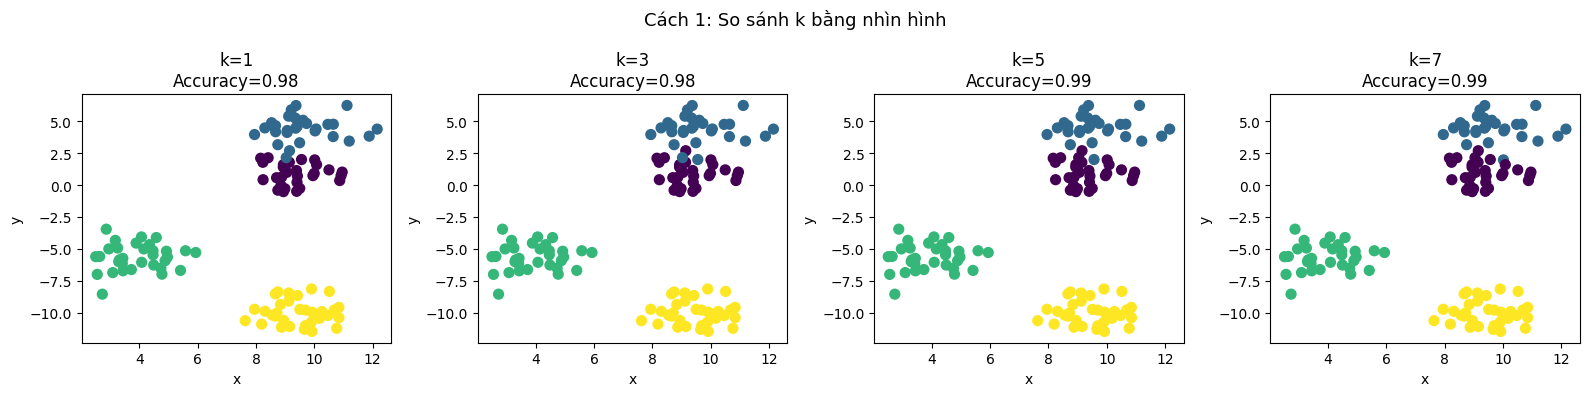

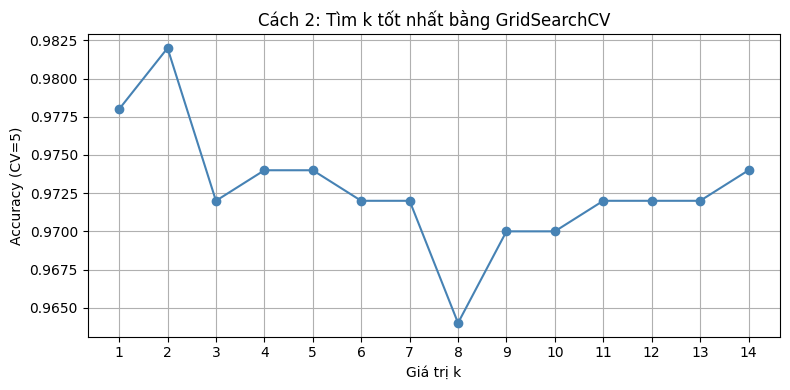

✅ k tốt nhất: {'n_neighbors': 2}
   Accuracy cao nhất: 0.9820

🔍 Điểm (1, 3) thuộc lớp: 0


In [1]:
"""Bài 2"""
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# ===================== DỮ LIỆU =====================

X, y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1, random_state=4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# ===================== CÁCH 1: NHÌN HÌNH (thủ công thử k) =====================

def knn_manual(X_train, X_test, y_train, y_test, k_values=[1, 3, 5, 7]):
    """Thử nhiều giá trị k và vẽ đồ thị để so sánh."""
    fig, axes = plt.subplots(1, len(k_values), figsize=(16, 4))
    fig.suptitle('Cách 1: So sánh k bằng nhìn hình', fontsize=13)

    for ax, k in zip(axes, k_values):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, marker='o', s=50, cmap='viridis')
        ax.set_title(f'k={k}\nAccuracy={acc:.2f}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')

    plt.tight_layout()
    plt.show()

knn_manual(X_train, X_test, y_train, y_test)

# ===================== CÁCH 2: TỰ ĐỘNG GridSearchCV =====================

def knn_gridsearch(X, y, k_range=range(1, 15)):
    """Tìm k tốt nhất tự động bằng GridSearchCV."""
    param_grid = {'n_neighbors': list(k_range)}
    knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
    knn_grid.fit(X, y)

    # Vẽ biểu đồ accuracy theo k
    results = knn_grid.cv_results_
    plt.figure(figsize=(8, 4))
    plt.plot(list(k_range), results['mean_test_score'], marker='o', color='steelblue')
    plt.xlabel('Giá trị k')
    plt.ylabel('Accuracy (CV=5)')
    plt.title('Cách 2: Tìm k tốt nhất bằng GridSearchCV')
    plt.xticks(list(k_range))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f'✅ k tốt nhất: {knn_grid.best_params_}')
    print(f'   Accuracy cao nhất: {knn_grid.best_score_:.4f}')
    return knn_grid.best_params_['n_neighbors']

best_k = knn_gridsearch(X, y)

# ===================== HÀM KNN TỰ CÀI ĐẶT (không dùng sklearn) =====================

def KNN(X_train, X_test, y_train, k):
    """Tự cài đặt K-NN từ đầu bằng numpy."""
    num_test  = X_test.shape[0]
    num_train = X_train.shape[0]

    # Tính ma trận khoảng cách Euclidean
    dist_matrix = np.zeros((num_test, num_train))
    for i in range(num_test):
        for j in range(num_train):
            dist_matrix[i, j] = np.sqrt(np.sum((X_test[i] - X_train[j]) ** 2))

    results = []
    for i in range(num_test):
        # Sắp xếp theo khoảng cách tăng dần, lấy k láng giềng gần nhất
        sorted_idx = np.argsort(dist_matrix[i])[:k]
        top_k_labels = y_train[sorted_idx]

        # Bình bầu: chọn class xuất hiện nhiều nhất
        classes = {}
        for label in top_k_labels:
            label = int(label)
            classes[label] = classes.get(label, 0) + 1
        results.append(max(classes, key=classes.get))

    return np.array(results)

# Kiểm tra hàm tự cài
X_test_1pt = np.array([(1, 3)])
pred = KNN(X_train, X_test_1pt, y_train, k=best_k)
print(f'\n🔍 Điểm (1, 3) thuộc lớp: {pred[0]}')

DEMO K-MEANS: Phân nhóm khách hàng


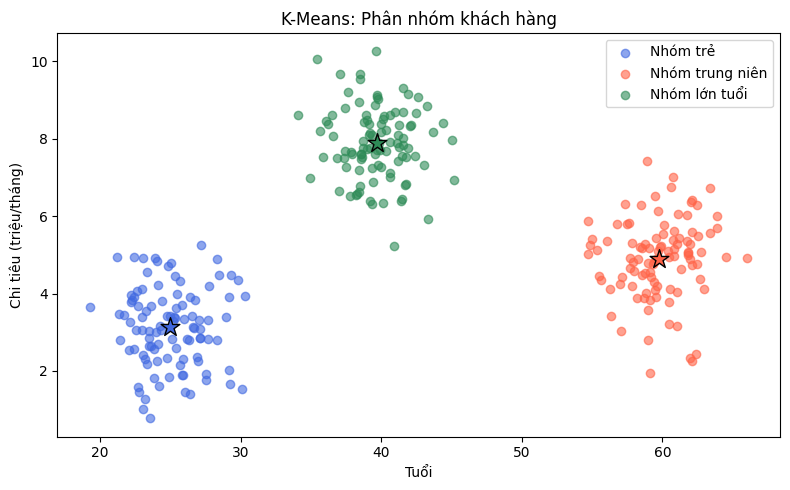

✅ Hoàn tất sau 3 vòng lặp

DEMO K-NN: Phân loại loài hoa Iris


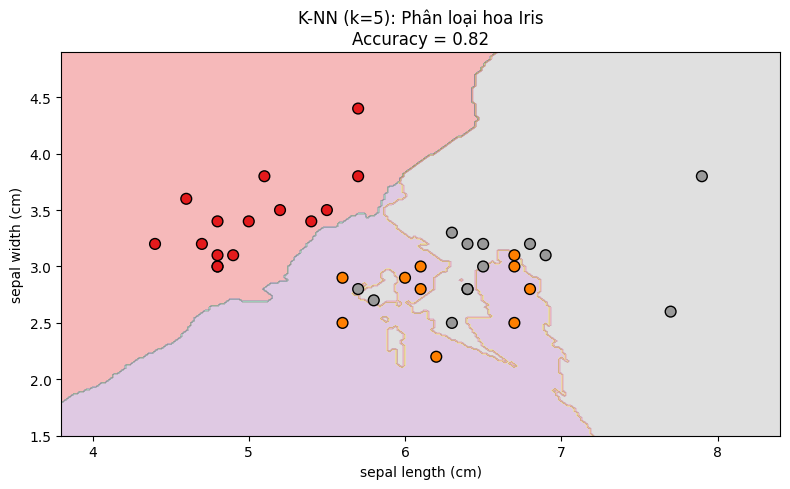

✅ Accuracy trên tập test: 0.8158



In [5]:
#Bài 3 – Demo ứng dụng cho cả 2 thuật toán
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.datasets import make_blobs, load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ===================== ĐỊNH NGHĨA HÀM K-MEANS THỦ CÔNG =====================

def kmeans(X, n_cluster=3, max_iter=300, visualize=False):
    """
    Thuật toán K-Means tự xây dựng để phục vụ hàm demo_kmeans
    """
    # 1. Khởi tạo ngẫu nhiên các tâm cụm từ tập dữ liệu
    random_indices = np.random.choice(X.shape[0], n_cluster, replace=False)
    centers = X[random_indices]

    times = 0
    for i in range(max_iter):
        times += 1
        # 2. Tính khoảng cách từ mỗi điểm đến các tâm cụm
        distances = cdist(X, centers, 'euclidean')

        # 3. Gán nhãn cho điểm dựa vào tâm cụm gần nhất
        labels = np.argmin(distances, axis=1)

        # 4. Cập nhật lại vị trí các tâm cụm mới
        new_centers = np.array([X[labels == k].mean(axis=0) for k in range(n_cluster)])

        # Nếu tâm cụm không thay đổi thì dừng vòng lặp
        if np.allclose(centers, new_centers):
            break
        centers = new_centers

    return centers, labels, times

# ===================== DEMO K-MEANS: Phân vùng khách hàng =====================

def demo_kmeans():
    """
    Ứng dụng: Phân nhóm khách hàng theo độ tuổi và chi tiêu.
    """
    print("=" * 50)
    print("DEMO K-MEANS: Phân nhóm khách hàng")
    print("=" * 50)

    np.random.seed(0)
    # Mô phỏng dữ liệu: (tuổi, chi tiêu/tháng)
    group1 = np.random.multivariate_normal([25, 3], [[5, 0], [0, 1]], 100)  # trẻ, chi tiêu ít
    group2 = np.random.multivariate_normal([40, 8], [[5, 0], [0, 1]], 100)  # trung niên, chi tiêu nhiều
    group3 = np.random.multivariate_normal([60, 5], [[5, 0], [0, 1]], 100)  # lớn tuổi, chi tiêu vừa
    X = np.concatenate([group1, group2, group3])

    # Chạy K-Means (Bây giờ hàm này đã hoạt động)
    centers, labels, times = kmeans(X, n_cluster=3, visualize=False)

    # Vẽ kết quả
    colors = ['royalblue', 'tomato', 'seagreen']
    labels_text = ['Nhóm trẻ', 'Nhóm trung niên', 'Nhóm lớn tuổi']
    plt.figure(figsize=(8, 5))
    for i in range(3):
        data = X[labels == i]
        plt.scatter(data[:, 0], data[:, 1], color=colors[i], alpha=0.6, label=labels_text[i])
        plt.scatter(centers[i][0], centers[i][1], color=colors[i], s=200, marker='*', edgecolors='black')
    plt.xlabel('Tuổi')
    plt.ylabel('Chi tiêu (triệu/tháng)')
    plt.title('K-Means: Phân nhóm khách hàng')
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f'✅ Hoàn tất sau {times} vòng lặp\n')

# ===================== DEMO K-NN: Phân loại loài hoa Iris =====================

def demo_knn():
    """
    Ứng dụng: Phân loại loài hoa Iris (dữ liệu chuẩn trong ML).
    """
    print("=" * 50)
    print("DEMO K-NN: Phân loại loài hoa Iris")
    print("=" * 50)

    iris = load_iris()
    X, y = iris.data[:, :2], iris.target  # chỉ lấy 2 đặc trưng để vẽ
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Vẽ vùng quyết định (Decision Boundary)
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
    scatter = plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='Set1', edgecolors='black', s=60)
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.title(f'K-NN (k=5): Phân loại hoa Iris\nAccuracy = {acc:.2f}')
    plt.tight_layout()
    plt.show()
    print(f'✅ Accuracy trên tập test: {acc:.4f}\n')

# ===================== CHẠY DEMO =====================
if __name__ == "__main__":
    demo_kmeans()
    demo_knn()

===========Bài tập về nhà==============


=============== BÀI 4 - K-MEANS: TÌM VỊ TRÍ ĐẶT TRẠM SẠC ===============


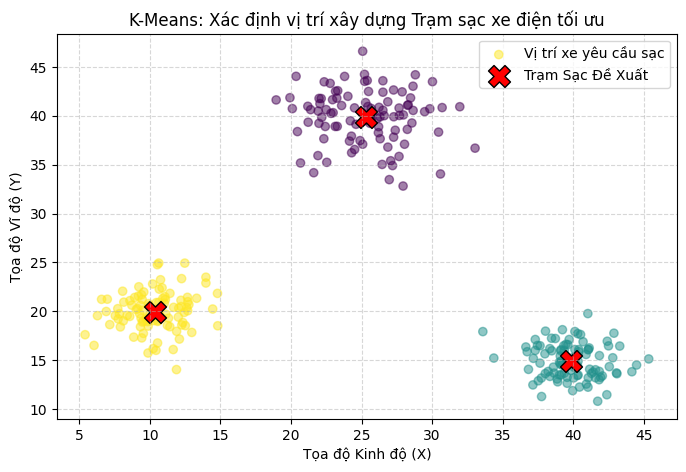


=============== BÀI 4 - K-NN: PHÁT HIỆN GIAN LẬN TÍN DỤNG ===============
Giao dịch mới 1 [Số tiền: 2.0tr, Khoảng cách: 8.0km] -> Trạng thái: ✅ HỢP PHÁP (Duyệt)
Giao dịch mới 2 [Số tiền: 30.0tr, Khoảng cách: 110.0km] -> Trạng thái: ⚠️ GIAN LẬN (Block)


In [6]:
#Bài 4
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier

# --- DEMO K-MEANS: TỐI ƯU VỊ TRÍ TRẠM SẠC ---
def homework_kmeans_charging_stations():
    print("\n" + "="*15 + " BÀI 4 - K-MEANS: TÌM VỊ TRÍ ĐẶT TRẠM SẠC " + "="*15)
    np.random.seed(10)
    # Giả lập 300 điểm tọa độ GPS yêu cầu sạc xe của khách hàng trong khu vực
    zone_A = np.random.normal(loc=[10, 20], scale=2, size=(100, 2))
    zone_B = np.random.normal(loc=[25, 40], scale=3, size=(100, 2))
    zone_C = np.random.normal(loc=[40, 15], scale=2, size=(100, 2))
    X_gps = np.concatenate([zone_A, zone_B, zone_C], axis=0)

    # Tìm 3 vị trí đặt trạm lý tưởng nhất
    kmeans_model = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
    labels = kmeans_model.fit_predict(X_gps)
    station_centers = kmeans_model.cluster_centers_

    # Trực quan đồ thị phân bổ trạm sạc điện
    plt.figure(figsize=(8, 5))
    plt.scatter(X_gps[:, 0], X_gps[:, 1], c=labels, cmap='viridis', alpha=0.5, label='Vị trí xe yêu cầu sạc')
    plt.scatter(station_centers[:, 0], station_centers[:, 1], color='red', marker='X', s=250, edgecolors='black', label='Trạm Sạc Đề Xuất')
    plt.title("K-Means: Xác định vị trí xây dựng Trạm sạc xe điện tối ưu")
    plt.xlabel("Tọa độ Kinh độ (X)")
    plt.ylabel("Tọa độ Vĩ độ (Y)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- DEMO K-NN: PHÁT HIỆN GIAN LẬN THẺ TÍN DỤNG ---
def homework_knn_fraud_detection():
    print("\n" + "="*15 + " BÀI 4 - K-NN: PHÁT HIỆN GIAN LẬN TÍN DỤNG " + "="*15)
    np.random.seed(7)

    # Đặc trưng: [Giá trị giao dịch (Triệu đồng), Khoảng cách xa nhà (Km)]
    normal_tx = np.random.normal(loc=[1.5, 5], scale=[1, 3], size=(80, 2))     # Hợp pháp
    fraud_tx = np.random.normal(loc=[25.0, 95], scale=[5, 15], size=(20, 2))   # Gian lận

    X_tx = np.concatenate([normal_tx, fraud_tx], axis=0)
    y_tx = np.concatenate([np.zeros(80), np.ones(20)])  # 0: Hợp pháp, 1: Gian lận

    # Huấn luyện bộ phân loại K-NN
    knn_model = KNeighborsClassifier(n_neighbors=3)
    knn_model.fit(X_tx, y_tx)

    # Giả lập phát sinh 2 giao dịch mới cần hệ thống quét tự động
    new_transactions = np.array([[2.0, 8.0], [30.0, 110.0]])
    predictions = knn_model.predict(new_transactions)

    # In kết quả kiểm tra
    for i, tx in enumerate(new_transactions):
        status = "⚠️ GIAN LẬN (Block)" if predictions[i] == 1 else "✅ HỢP PHÁP (Duyệt)"
        print(f"Giao dịch mới {i+1} [Số tiền: {tx[0]}tr, Khoảng cách: {tx[1]}km] -> Trạng thái: {status}")

if __name__ == "__main__":
    homework_kmeans_charging_stations()
    homework_knn_fraud_detection()


=============== BÀI 5 - LINEAR REGRESSION: DỰ ĐOÁN GIÁ NHÀ ===============
🏠 Dự báo giá của căn nhà rộng 85 m2 là: 4.72 Tỷ đồng


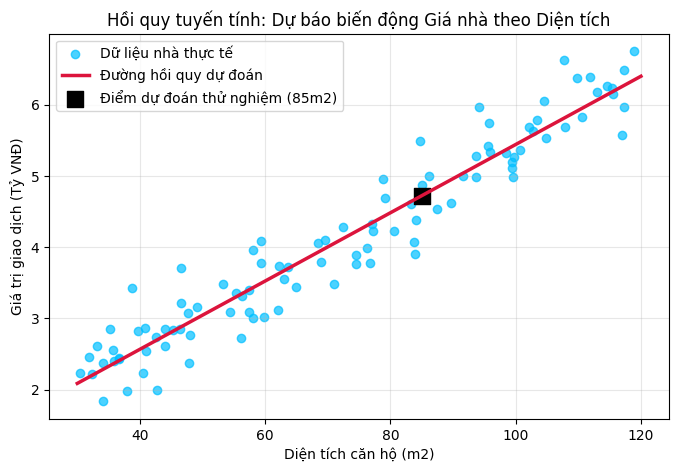

In [8]:
#Bài 5
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def homework_linear_regression_housing():
    print("\n" + "="*15 + " BÀI 5 - LINEAR REGRESSION: DỰ ĐOÁN GIÁ NHÀ " + "="*15)
    np.random.seed(42)

    # Tạo dữ liệu diện tích nhà (m2) từ 30 đến 120m2
    X_area = 30 + 90 * np.random.rand(100, 1)
    # Giá nhà tương ứng (tỷ đồng) = 0.05 * diện tích + độ nhiễu thị trường
    y_price = 0.05 * X_area + 0.5 + np.random.randn(100, 1) * 0.4

    # Khởi tạo và huấn luyện mô hình Hồi quy tuyến tính
    lr_model = LinearRegression()
    lr_model.fit(X_area, y_price)

    # Dự đoán đường thẳng xu hướng giá trị
    X_line = np.linspace(30, 120, 100).reshape(-1, 1)
    y_line = lr_model.predict(X_line)

    # Thử nghiệm dự đoán căn nhà có diện tích cụ thể: 85m2
    test_house = np.array([[85.0]])
    predicted_price = lr_model.predict(test_house)
    print(f"🏠 Dự báo giá của căn nhà rộng 85 m2 là: {predicted_price[0][0]:.2f} Tỷ đồng")

    # Trực quan hóa đường hồi quy lý thuyết
    plt.figure(figsize=(8, 5))
    plt.scatter(X_area, y_price, color='deepskyblue', alpha=0.7, label='Dữ liệu nhà thực tế')
    plt.plot(X_line, y_line, color='crimson', linewidth=2.5, label='Đường hồi quy dự đoán')
    plt.scatter(test_house, predicted_price, color='black', marker='s', s=120, label='Điểm dự đoán thử nghiệm (85m2)')
    plt.title("Hồi quy tuyến tính: Dự báo biến động Giá nhà theo Diện tích")
    plt.xlabel("Diện tích căn hộ (m2)")
    plt.ylabel("Giá trị giao dịch (Tỷ VNĐ)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    homework_linear_regression_housing()